In [1]:
import sys
sys.path.append('C:\\project_WWTP\\python')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from scipy.stats import zscore
import scipy.stats as stats
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pickle

import notebook.feature.WF_feature_selection as wf_fs
import notebook.feature.feature_engineering as feat_eng

In [2]:
BASE_DIR = Path.cwd().resolve().parent.parent

In [3]:
DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "model"
RESULTS_DIR = BASE_DIR / "results" / "DL"
NOTEBOOK_DIR = BASE_DIR / "notebook" / "DL"
OUTPUT_DIR = DATA_DIR / "output"
FEATURE_DIR = DATA_DIR / "features"

MODEL_SAVE_DIR = MODEL_DIR
SCALER_SAVE_DIR = MODEL_DIR

RESULTS_SAVE_DIR = RESULTS_DIR
PLOTS_SAVE_DIR = RESULTS_DIR / "plots"
METRICS_SAVE_DIR = RESULTS_DIR / "metrics"

In [4]:
MODE_CONFIGS = {
    "toc": {
        "hidden_size": 64,         # ARX 하이브리드와 동일
        "num_layers": 1,
        "dropout": 0.3,
        "learning_rate": 5e-4,
        "batch_size": 1024,
        "window_size": 60,  
        "output_size": 1, 
        "horizon": 1,
        "target_transform": "diff", # ARX 하이브리드: residual(차분) 예측
    },
    "ss": {
        "hidden_size": 256,
        "num_layers": 2,    
        "dropout": 0.2,     
        "learning_rate": 2e-3,
        "batch_size": 2048,   
        "window_size": 48,  
        "output_size": 1, 
        "horizon": 1,
    },
    "tn": {
        "hidden_size": 512,
        "num_layers": 2,
        "dropout": 0.2,
        "learning_rate": 2e-3,
        "batch_size": 2048,
        "window_size": 48,  
        "output_size": 1, 
        "horizon": 1,
    },
    "tp": {
        "hidden_size": 384,
        "num_layers": 1,
        "dropout": 0.1,
        "learning_rate": 2e-3,
        "batch_size": 1024,
        "window_size": 48,
        "output_size": 1, 
        "horizon": 1,
    },
    "flux": {
        "hidden_size": 512,
        "num_layers": 4,
        "dropout": 0.2,
        "learning_rate": 2e-4,
        "batch_size": 2048,
        "window_size": 48,
        "output_size": 1, 
        "horizon": 1,
    },
    "ph": {
        "hidden_size": 512,
        "num_layers": 1,
        "dropout": 0.1,
        "learning_rate": 2e-3,
        "batch_size": 1024,
        "window_size": 48,  
        "output_size": 1, 
        "horizon": 1,
    },
}

In [5]:
MODE = "toc"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if MODE not in MODE_CONFIGS:
    raise ValueError(f"Unknown MODE: {MODE}. Available modes: {list(MODE_CONFIGS.keys())}")

CONFIG = MODE_CONFIGS[MODE]
WINDOW_SIZE = CONFIG["window_size"]
HORIZON = CONFIG["horizon"]

TOC_TARGET_TRANSFORM = CONFIG.get("target_transform", "diff") if MODE == "toc" else "abs"
if MODE == "toc" and TOC_TARGET_TRANSFORM not in ["diff", "abs"]:
    raise ValueError(f"Invalid toc target_transform: {TOC_TARGET_TRANSFORM}. Use 'diff' or 'abs'.")

LSTM_CONFIG = {
    "hidden_size": CONFIG["hidden_size"],
    "num_layers": CONFIG["num_layers"],
    "dropout": CONFIG["dropout"],
    "output_size": CONFIG["output_size"],
    "bidirectional": False,
    "attn_embed_dim":  CONFIG.get("attn_embed_dim",  64),
    "attn_num_heads":  CONFIG.get("attn_num_heads",  4),
    "history_steps":   CONFIG.get("history_steps",   [12, 24, 36, 48]),
}

TRAINING_CONFIG = {
    "batch_size": CONFIG["batch_size"],
    "learning_rate": CONFIG["learning_rate"],
    "num_epochs": 200,
    "patience": 30,
    "optimizer": "adam",
    "loss_function": "mse",
}

LC_SPLIT_RATIOS = {
    "train": 0.8,
    "val": 0.1,
    "test": 0.1,
}

SPLIT_RATIOS = {
    "train": 0.7,
    "val": 0.2,
    "test": 0.1,
}

FLOW_TARGET = "Q_in"
TOC_TARGET = "TOC_VU"
SS_TARGET = "SS_VU"
TN_TARGET = "TN_VU"
TP_TARGET = "TP_VU"
FLUX_TARGET = "FLUX_VU"
PH_TARGET = "PH_VU"

VISUALIZATION_CONFIG = {
    "dpi": 300,
    "figsize": (10, 6),
    "font_family": "Malgun Gothic",
    "grid": True,
}

RANDOM_SEED = 42

TIME_COL = "SYS_TIME"

# TOC ARX 하이브리드 고정 피처 (ARXLSTMAttention 모델용)
# 순서 중요: [0] TOC_VU_lag1 이 ARX baseline으로 사용됨
TOC_ARX_FEATURES = [
    'TOC_VU_lag1', 'TN_VU_lag1',
    'TOC_VU_lag2', 'TN_VU_lag2',
    'TOC_load', 'TN_load',
    'TOC_load_per_air', 'TN_load_per_air',
    'aeration_total', 'pump_total',
    'WATER_TEMP_in',
]

In [6]:
def load_data(DATA_DIR):
    dfs = {}

    dfs['flow'] = pd.read_csv(DATA_DIR / "actual/FLOW_extended.csv")
    dfs['tms'] = pd.read_csv(DATA_DIR / "actual/TMS_extended.csv")
    for station_id in ["368", "541", "569"]:
        aws_path = DATA_DIR / f"actual/AWS_{station_id}.csv"
        df = pd.read_csv(aws_path)
        if "datetime" in df.columns:
            time_col = df["datetime"]
            df = df.drop(columns=["datetime","YYMMDDHHMI","STN"], errors="ignore")
            df = df.add_suffix(f"_{station_id}")
            df["SYS_TIME"] = time_col
        else:
            df = df.drop(columns=["YYMMDDHHMI", "STN"], errors="ignore")
            df = df.add_suffix(f"_{station_id}")
        dfs[f"aws{station_id}"] = df

    return dfs

In [7]:
def set_datetime_index(df, time_col):
    out = df.copy()
    
    if time_col not in out.columns:
        raise ValueError(f"시간 컬럼 '{time_col}'이 데이터프레임에 없습니다. 데이터프레임의 컬럼: {out.columns.tolist()}")
    
    out[time_col] = pd.to_datetime(out[time_col], errors="coerce")
    out = out.dropna(subset=[time_col])
    out = out.set_index(time_col).sort_index()
    return out

In [8]:
def align_data(dfs):
    aligned_dfs = {}
    for name, df in dfs.items():
        time_col = TIME_COL
        df_aligned = set_datetime_index(df, time_col)

        df_aligned = df_aligned.resample("1min").ffill()

        aligned_dfs[name] = df_aligned
            
    return aligned_dfs


In [9]:
def merge_data(dfs):

    valid = {}
    merged_dfs = {}

    for name, df in dfs.items():
        df2 = df.sort_index()
        if df2.index.has_duplicates:
            df2 = df2[~df2.index.duplicated(keep="last")]
        valid[name] = df2

    for name, df in valid.items():
        if name == "flow":
            merged_dfs[name] = pd.concat([
                df,
                valid["aws368"],
                valid["aws541"],
                valid["aws569"],
            ], axis = 1, join = "inner")

        if name == "tms":
            merged_dfs[name] = pd.concat([
                valid["flow"],
                df,
                valid["aws368"],
                valid["aws541"],
                valid["aws569"]
            ], axis = 1, join = "inner")

    return merged_dfs

In [10]:
@dataclass
class ImputationConfig:
    short_term_hours: int = 3
    medium_term_hours: int = 12
    long_term_hours: int = 48
    ewma_span: int = 6

@dataclass
class OutlierConfig:
    method: str = "iqr"
    iqr_threshold: float = 1.5
    zscore_threshold: float = 3.0
    require_both: bool = True

In [11]:
def impute_missing(df, freq = "1h", config = ImputationConfig()):
    df_out = df.copy()

    freq_td = pd.Timedelta(freq)
    freq_hours = freq_td.total_seconds() / 3600

    mask_dict = {}

    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue

        series = df[col].copy()
        original_missing = series.isna()

        mask_dict[f"{col}_is_missing"] = original_missing.astype(int)

        limit_short = max(1, int(config.short_term_hours / freq_hours))
        series_ffill = series.ffill(limit = limit_short)
        ffill_mask = original_missing & ~series_ffill.isna()
        mask_dict[f"{col}_imputed_ffill"] = ffill_mask.astype(int)

        still_missing = series_ffill.isna()
        if still_missing.sum() > 0:
            ewma_span = max(1, int(config.ewma_span / freq_hours))
            series_ewma = series_ffill.ewm(span=ewma_span, adjust=False).mean()
            
            limit_medium = max(1, int(config.medium_term_hours / freq_hours))
            missing_groups = (still_missing != still_missing.shift()).cumsum()
            missing_lengths = still_missing.groupby(missing_groups).transform("sum")
            
            medium_mask = still_missing & (missing_lengths > limit_short) & (missing_lengths <= limit_medium)
            series_ffill[medium_mask] = series_ewma[medium_mask]
            mask_dict[f"{col}_imputed_ewma"] = medium_mask.astype(int)
        else:
            mask_dict[f"{col}_imputed_ewma"] = pd.Series(0, index=df.index, dtype=int)

        still_missing_long = series_ffill.isna()
        if still_missing_long.sum() > 0:
            long_ewma_span = max(1, int(config.ewma_span * 4 / freq_hours))
            series_long_ewma = series_ffill.ewm(span=long_ewma_span, adjust=False).mean()
            
            long_mask = still_missing_long
            series_ffill[long_mask] = series_long_ewma[long_mask]
            mask_dict[f"{col}_imputed_long_ewma"] = long_mask.astype(int)
        else:
            mask_dict[f"{col}_imputed_long_ewma"] = pd.Series(0, index=df.index, dtype=int)

        df_out[col] = series_ffill

    df_mask = pd.DataFrame(mask_dict, index=df.index)
    
    return df_out, df_mask

In [12]:
def imputate_data(dfs):
    config_impute = ImputationConfig()
    imputed_dfs = {}
    mask_imputed_dfs = {}

    for name, df in dfs.items():
        print(f"\n{'='*60}")
        print(f"{name} 결측치 처리")
        print(f"{'='*60}")
        print(f"결측치 처리 후")
        print(f"  총 결측치 {df.isna().sum().sum()}")
        print(f"  결측치 있는 컬럼: {(df.isna().sum() > 0).sum()}")

        df_imputed, mask_imputed = impute_missing(df, freq="1min", config = config_impute)

        imputed_dfs[name] = df_imputed
        mask_imputed_dfs[name] = mask_imputed

        print(f"\n결측치 처리 후")
        print(f"  총 결측치 {df_imputed.isna().sum().sum()}")
        print(f"  이후 shape: {df_imputed.shape}")
        print(f"  마스크 shape: {mask_imputed.shape}")

    return imputed_dfs, mask_imputed_dfs

In [13]:
def outliers_domain(series, col_name):
    """
    이상치 탐지 기반 이상치 제거 (법령 기준 반영)

    법령 기준 (방류수 수질기준):
    - TOC: ≤15 mg/L
    - SS: ≤10 mg/L
    - PH: 5.8~8.5
    - TN: ≤20 mg/L
    - TP: ≤0.5 mg/L

    """
    outliers = pd.Series([False] * len(series), index = series.index)

    if not pd.api.types.is_numeric_dtype(series):
        return outliers

    regulatory_rules = {
        "TOC_VU": (0, 30),
        "SS_VU": (0, 20),
        "PH_VU": (4.3, 10.0),
        "TN_VU": (0, 20),
        "TP_VU": (0, 1.0),
        "FLUX_VU": (0, 12.0),
    }

    if col_name in regulatory_rules:
        lower, upper = regulatory_rules[col_name]
        outliers = (series < lower) | (series > upper)
        return outliers

    physical_rules = {
        "level_TankA": (0, 10),
        "level_TankB": (0, 10),
        "TA": (-30, 45),
        "HM": (0, 100),
        "TD": (-40, 35),
    }

    if col_name in physical_rules:
        lower, upper = physical_rules[col_name]
        outliers = (series < lower) | (series > upper)
    elif "RN_" in col_name:
        outliers = (series < 0) | (series > 300)
    elif "flow" in col_name.lower() or "flux" in col_name.lower():
        valid_values = series.dropna()
        if len(valid_values) > 0:
            outliers = (series < 0) | (series > valid_values.quantile(0.99) * 3)
    else:
        valid_values = series.dropna()
        if len(valid_values) > 0:
            outliers = (series < 0) | (series > valid_values.quantile(0.999) * 2)

    return outliers

In [14]:
def outliers_statistical(series, 
                        method = 'iqr', 
                        iqr_threshold = 1.5, 
                        zscore_threshold = 3.0):
    outliers = pd.Series([False] * len(series), index=series.index)

    if not pd.api.types.is_numeric_dtype(series):
        return outliers
    
    if method == 'iqr':
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - iqr_threshold * IQR
        upper = Q3 + iqr_threshold * IQR
        outliers = (series < lower) | (series > upper)
    
    elif method == 'zscore':
        valid_mask = ~series.isna()
        if valid_mask.sum() > 0:
            z_scores = np.abs(zscore(series[valid_mask]))
            outliers[valid_mask] = z_scores > zscore_threshold
    
    return outliers

In [15]:
def process_outliers(df, config = OutlierConfig(), ewma_span = 12):
    df_out = df.copy()
    mask_dict = {}

    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue

        series = df[col].copy()

        domain_outliers = outliers_domain(series, col)

        stats_outliers = outliers_statistical(series, method = config.method, iqr_threshold=config.iqr_threshold, zscore_threshold=config.zscore_threshold)

        if config.require_both:
            final_outliers = domain_outliers & stats_outliers
        else:
            final_outliers = domain_outliers | stats_outliers

        mask_dict[f"{col}_outlier_domain"] = domain_outliers.astype(int)
        mask_dict[f"{col}_outlier_stats"] = stats_outliers.astype(int)
        mask_dict[f"{col}_outlier_final"] = final_outliers.astype(int)

        if final_outliers.sum() > 0:
            series_clean = series.copy()
            series_clean[final_outliers] = np.nan
            
            series_ewma = series_clean.ewm(span=ewma_span, adjust=False).mean()
            series[final_outliers] = series_ewma[final_outliers]
            
            mask_dict[f"{col}_outlier_replaced_ewma"] = final_outliers.astype(int)
        else:
            mask_dict[f"{col}_outlier_replaced_ewma"] = pd.Series(0, index=df.index, dtype=int)

        df_out[col] = series

    df_mask = pd.DataFrame(mask_dict, index=df.index)

    return df_out, df_mask

In [16]:
def handle_outliers(dfs):
    config_outlier = OutlierConfig()
    processed_dfs = {}
    mask_processed_dfs = {}

    for name, df in dfs.items():
        print(f"\n{'='*60}")
        print(f"{name} 이상치 처리")
        print(f"{'='*60}")

        df_outlier, mask_outlier = process_outliers(df, config = config_outlier, ewma_span = 12)

        processed_dfs[name] = df_outlier
        mask_processed_dfs[name] = mask_outlier

    return processed_dfs, mask_processed_dfs

In [17]:
def resample_data(df, freq = "30min", rain_cols=None, other_cols=None):
    if not isinstance(df.index, pd.DatetimeIndex) :
        raise ValueError("리샘플링을 위해서는 DatetimeIndex가 필요합니다.")
    
    numeric_cols = df.select_dtypes(include = [np.number]).columns
    df_numeric = df[numeric_cols]

    agg_dict = {}
    for col in numeric_cols:
        if col.startswith("RN_") or col.startswith("AR_") or col == "FLUX_VU":
            agg_dict[col] = "sum"
        else:
            agg_dict[col] = "mean"
    
    return df_numeric.resample(freq).agg(agg_dict)


In [18]:
def preprocess_data(dfs):
    aligned_dfs = align_data(dfs)

    if 'tms' in aligned_dfs and 'FLUX_VU' in aligned_dfs['tms'].columns:
        flux = aligned_dfs['tms']['FLUX_VU'].copy()
        flux_diff = flux.diff()
        reset_mask = flux_diff < 0
        flux_diff[reset_mask] = flux[reset_mask]
        flux_diff.iloc[0] = 0
        flux_diff = flux_diff.clip(lower=0)
        aligned_dfs['tms']['FLUX_VU'] = flux_diff
        print(f"  FLUX_VU 차분 처리 완료 (적립 증분 리셋 인원: {reset_mask.sum()}건 처리)")

    merged_dfs = merge_data(aligned_dfs)

    imputed_dfs, mask_imputed_dfs = imputate_data(merged_dfs)

    processed_dfs, mask_process_dfs = handle_outliers(imputed_dfs)

    resample_dfs = {}
    for name, df in processed_dfs.items():
        resample_dfs[name] = resample_data(df, freq="30min")

    mode = MODE

    MODE_CFG = {
        "flow": ("flow", [FLOW_TARGET]),
        "toc":  ("tms",  [TOC_TARGET]),
        "ss":   ("tms",  [SS_TARGET]),
        "tn":   ("tms",  [TN_TARGET]),
        "tp":   ("tms",  [TP_TARGET]),
        "flux": ("tms",  [FLUX_TARGET]),
        "ph":   ("tms",  [PH_TARGET]),
    }

    if mode not in MODE_CFG:
        raise ValueError(f"Unknown MODE: {mode}")
    
    source_key, target_col = MODE_CFG[mode]

    for name, df0 in resample_dfs.items():
        df = df0.loc[:, ~df0.columns.duplicated()].copy()

        if name == "flow":
            df = df.drop(columns=["flow_TankA", "flow_TankB"], errors="ignore")

        tgt_in_df = [c for c in target_col if c in df.columns]
        if tgt_in_df:
            df = feat_eng.add_target_lag_features(df, tgt_in_df, min_lag=2)
            print(f" lag 특성 추가 ({name}): {tgt_in_df}")
            if mode == "toc":
                for col in tgt_in_df:
                    if col in df.columns:
                        df[f"{col}_tlag_1"] = df[col].shift(1)
                tlag1_added = [f"{c}_tlag_1" for c in tgt_in_df]
                print(f"  TOC lag 특성 추가: {tlag1_added}")

        if tgt_in_df:
            y_part = df[tgt_in_df].copy()
            base = df.drop(columns=tgt_in_df)
        else:
            y_part = None
            base = df

        if mode in feat_eng.DATA_LEAKAGE_CONFIG:
            all_process_vars = ["TOC_VU", "SS_VU", "TN_VU", "TP_VU", "FLUX_VU", "PH_VU"]
            target_vars = set(feat_eng.DATA_LEAKAGE_CONFIG[mode]["target"])
            safe_vars = set(feat_eng.DATA_LEAKAGE_CONFIG[mode]["safe_process_features"])
            
            unsafe_vars = [v for v in all_process_vars if v not in target_vars and v not in safe_vars and v in base.columns]
            if unsafe_vars:
                print(f"  데이터 누수 방지 ({name}): {unsafe_vars} 제거")
                base = base.drop(columns=unsafe_vars)

        base = feat_eng.add_rain_features(base)
        base = feat_eng.add_station_agg_rain_features(base)
        base = feat_eng.add_weather_features(base)
        base = feat_eng.add_process_features(base)
        base = feat_eng.add_temporal_features(base)
        base = feat_eng.add_time_features(base)

        if "weekday" not in base.columns and "dayofweek" in base.columns:
            base["weekday"] = base["dayofweek"]
        if "iso_week" not in base.columns and isinstance(base.index, pd.DatetimeIndex):
            base["iso_week"] = base.index.isocalendar().week.astype(int).to_numpy()
        if "hour_x_weekday" not in base.columns:
            if "hour" in base.columns and "weekday" in base.columns:
                base["hour_x_weekday"] = base["hour"] * base["weekday"]
            elif "hour" in base.columns and "dayofweek" in base.columns:
                base["hour_x_weekday"] = base["hour"] * base["dayofweek"]

        if y_part is not None:
            df_fe = base.join(y_part, how="left")
        else:
            df_fe = base

        resample_dfs[name] = df_fe.dropna()

    source_data = resample_dfs[source_key]

    # =========================================================================
    # TOC ARX 모드: 고정 11 피처 사용, walk-forward 특성 선택 생략
    # ARX_LSTM_Attention 하이브리드와 동일한 피처 세트
    # =========================================================================
    if mode == "toc":
        arx = source_data.copy()

        # ARX 하이브리드와 동일한 피처 계산 (30분 리샘플 기준)
        arx['TOC_VU_lag1']      = source_data['TOC_VU'].shift(1)
        arx['TN_VU_lag1']       = source_data['TN_VU'].shift(1)
        arx['TOC_VU_lag2']      = source_data['TOC_VU'].shift(2)
        arx['TN_VU_lag2']       = source_data['TN_VU'].shift(2)
        arx['aeration_total']   = source_data['wind1'] + source_data['wind2']
        arx['pump_total']       = source_data['pumpA'] + source_data['pumpB'] + source_data['pumpC']
        arx['TOC_load']         = source_data['TOC_in'] * source_data['flow_TankA']
        arx['TN_load']          = source_data['TN_in']  * source_data['flow_TankA']
        arx['TOC_load_per_air'] = arx['TOC_load'] / (arx['aeration_total'] + 1e-6)
        arx['TN_load_per_air']  = arx['TN_load']  / (arx['aeration_total'] + 1e-6)
        # WATER_TEMP_in 은 source_data에 이미 존재

        missing_arx = [f for f in TOC_ARX_FEATURES if f not in arx.columns]
        if missing_arx:
            raise ValueError(f"[TOC ARX] 누락 피처: {missing_arx}\n"
                             f"source_data 컬럼: {list(source_data.columns)}")

        arx = arx.dropna(subset=TOC_ARX_FEATURES + target_col).reset_index(drop=True)

        X_all_arx         = arx[TOC_ARX_FEATURES].values
        y_arx             = arx[target_col]
        feature_names_all = TOC_ARX_FEATURES

        y_abs_full = None
        if TOC_TARGET_TRANSFORM == "diff":
            y_abs_full = y_arx.copy()
            y_arx      = y_arx.diff()
            valid      = ~y_arx.isna().any(axis=1)
            y_arx      = y_arx[valid]
            y_abs_full = y_abs_full[valid]
            X_all_arx  = X_all_arx[valid.values]
            print(f"\n[TOC ARX target: DIFF]")
            print(f"  range: {float(y_arx.values.min()):.4f} ~ {float(y_arx.values.max()):.4f}")
            print(f"  mean={float(y_arx.values.mean()):.4f}, std={float(y_arx.values.std()):.4f}")

        print(f"\n{'='*70}")
        print(f"TOC ARX 피처 ({len(TOC_ARX_FEATURES)}개):")
        for i, f in enumerate(TOC_ARX_FEATURES, 1):
            print(f"  {i:2d}. {f}")
        print(f"샘플 수: {len(X_all_arx)}")

        recommended_idx = np.arange(len(TOC_ARX_FEATURES))
        recommended_df = pd.DataFrame({
            "index": recommended_idx,
            "feature_name": TOC_ARX_FEATURES,
        })
        FEATURE_DIR.mkdir(parents=True, exist_ok=True)
        recommended_df.to_csv(FEATURE_DIR / f"{MODE}_recommended_features.csv", index=False)
        print(f"추천 피처 저장: {FEATURE_DIR / f'{MODE}_recommended_features.csv'}")

        return X_all_arx, y_arx, recommended_idx, feature_names_all, y_abs_full

    # =========================================================================
    # 표준 모드 (toc 외): walk-forward 특성 선택
    # =========================================================================
    X_all = source_data.drop(columns=target_col).values
    y = source_data[target_col]
    
    feature_names_all = source_data.drop(columns=target_col).columns.tolist()

    y_abs_full = None
    
    print(f"\n{'='*70}")
    print(f"전체 특성 정보")
    print(f"{'='*70}")
    print(f"전체 특성 개수: {len(feature_names_all)}")
    print(f"샘플 개수: {len(X_all)}")
    print(f"타겟 개수: {y.shape[1]}")

    target_lag_features = [f for f in feature_names_all if "_tlag_" in f or "_troll_" in f or "_tdiff_" in f or "_tpct_" in f or "_tewma_" in f]
    print(f"타겟 lag 특성 개수: {len(target_lag_features)}")
    if target_lag_features:
        print(f"타겟 lag 특성 목록:")
        for f in target_lag_features:
            print(f"  - {f}")

    wf_selector = wf_fs.WalkForwardFeatureSelector(
        X=X_all,
        y=y,
        feature_names=feature_names_all,
        n_splits=5,
        train_size=700,
        val_size=200,
        test_size=200,
        window_step=200,
    )

    results = wf_selector.run(model_type="rf", verbose=True)

    print("\n" + "="*70)
    print("WALK-FORWARD VALIDATION 결과 요약")
    print("="*70)
    print(f"원본 특성: {results['n_features_original']}")
    print(f"선택 특성 (평균): {results['n_selected_mean']:.1f} ± {results['n_selected_std']:.1f}")
    print(f"특성 감소율: {(1 - results['n_selected_mean']/results['n_features_original'])*100:.1f}%")
    print(f"\n정확한 특성 (모든 폴드에서 선택): {len(results['stable_features'])}")

    MIN_FEATURES = 10

    if mode in ["flux", "tp"]:
        sr = 0.4
        recommended_idx = wf_selector.get_recommended_features(stability_ratio=sr)
        print(f"\n {mode.upper()} 모드: stability_ratio={sr}")

        if len(recommended_idx) < MIN_FEATURES:
            importance_mean = np.mean(wf_selector.feature_importance_folds, axis=0)
            top_idx = np.argsort(importance_mean)[::-1][:MIN_FEATURES]
            recommended_idx = np.sort(np.unique(np.concatenate([recommended_idx, top_idx])))
            print(f"  중요도 기반 상위 {MIN_FEATURES}개 특성 보충: {len(recommended_idx)}개 특성 선택")
    else:
        sr = 0.4
        recommended_idx = wf_selector.get_recommended_features(stability_ratio=sr)

    if mode == "ph":
        mandatory_ph_features = ["month", "iso_week", "hour_sin", "hour_cos"]
        mandatory_ph_idx = np.array([
            i for i, fname in enumerate(feature_names_all)
            if fname in mandatory_ph_features
        ], dtype=int)

        before_n = len(recommended_idx)
        if mandatory_ph_idx.size > 0:
            recommended_idx = np.sort(np.unique(np.concatenate([recommended_idx, mandatory_ph_idx])))
        added_n = len(recommended_idx) - before_n
        print(f"\n[PH] forced time features: {mandatory_ph_idx.size} (newly added: {added_n})")

        missing_ph_features = [f for f in mandatory_ph_features if f not in feature_names_all]
        if missing_ph_features:
            print(f"[PH] warning: missing time features in source_data: {missing_ph_features}")

    recommended_names = [feature_names_all[i] for i in recommended_idx]
    
    print(f"\n추천 특성 (stability_ratio={sr}): {len(recommended_idx)}")
    print(f"특성 개수: {len(recommended_idx)}/{len(feature_names_all)}")
    print(f"\n추천 특성 목록:")
    for i, (idx, name) in enumerate(zip(recommended_idx, recommended_names), 1):
        print(f"  {i:3d}. [{idx:3d}] {name}")

    X = X_all[:, recommended_idx]
    
    print(f"\n{'='*70}")
    print(f"특성 선택 결과 요약")
    print(f"{'='*70}")
    print(f"원본 X shape: {X_all.shape}")
    print(f"선택된 X shape: {X.shape}")
    print(f"선택 비율: {X.shape[1]/X_all.shape[1]*100:.1f}%")

    recommended_df = pd.DataFrame({
        "index": recommended_idx,
        "feature_name": recommended_names,
    })
    FEATURE_DIR.mkdir(parents=True, exist_ok=True)
    recommended_df.to_csv(
        FEATURE_DIR / f"{MODE}_recommended_features.csv", 
        index=False
    )
    print(f"\n추천 특성 목록 저장: {FEATURE_DIR / f'{MODE}_recommended_features.csv'}")

    return X, y, recommended_idx, feature_names_all, y_abs_full

In [19]:
class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, x):
        self.mean_ = x.mean(axis = 0, keepdims = True)
        self.std_ = x.std(axis = 0, keepdims = True) + 1e-8
        return self
    
    def transform(self, x):
        return (x - self.mean_) / self.std_
    
    def inverse_transform(self, x):
        return x * self.std_ + self.mean_
    
class RobustScaler:
    """IQR 기반 스케일러"""
    def __init__(self):
        self.median_ = None
        self.iqr_    = None
    
    def fit(self, x):
        self.median_ = np.median(x, axis=0, keepdims=True)
        q75 = np.percentile(x, 75, axis=0, keepdims=True)
        q25 = np.percentile(x, 25, axis=0, keepdims=True)
        self.iqr_ = (q75 - q25) + 1e-8
        return self
    
    def transform(self, x):
        return (x - self.median_) / self.iqr_
    
    def inverse_transform(self, x):
        return x * self.iqr_ + self.median_


In [20]:
class TimeSeriesWindowDataset(Dataset):
    def __init__(self, X, y, window_size, horizon):
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)
        self.window_size = window_size
        self.horizon = horizon

        if self.y.ndim == 1:
            self.y = self.y.unsqueeze(1)

        self.max_start = len(self.X) - self.window_size - self.horizon + 1
        if self.max_start <= 0:
            raise ValueError("데이터 길이가 window_size + horizon 보다 짧습니다.")
        
    def __len__(self):
        return self.max_start
    
    def __getitem__(self, idx):
        
        x_seq = self.X[idx : idx + self.window_size]
        y_t = self.y[idx + self.window_size + self.horizon - 1]
        return x_seq, y_t.reshape(-1)

In [21]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_size = 64, num_layers = 2, dropout = 0.2, out_size = 1, use_attention=True):
        super(LSTMRegressor, self).__init__()
        self.hidden_size = hidden_size
        self.use_attention = use_attention

        self.lstm = nn.LSTM(
            input_size = n_features,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout if num_layers > 1 else 0.0,
        )

        lstm_out_size = hidden_size

        if self.use_attention:
            self.layer_norm1 = nn.LayerNorm(lstm_out_size)
            self.attention = nn.MultiheadAttention(
                embed_dim=lstm_out_size,
                num_heads=4,
                dropout=dropout,
                batch_first=True
            )
            self.layer_norm2 = nn.LayerNorm(lstm_out_size)

        if hidden_size >= 256 and MODE in ["flow", "toc", "ss"]:
            self.head = nn.Sequential(
                nn.Linear(lstm_out_size, lstm_out_size // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(lstm_out_size // 2, lstm_out_size // 4),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(lstm_out_size // 4, lstm_out_size // 8),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(lstm_out_size // 8, out_size)
            )

        elif hidden_size >= 256:
            self.head = nn.Sequential(
                nn.Linear(lstm_out_size, lstm_out_size // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(lstm_out_size // 2, lstm_out_size // 4),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(lstm_out_size // 4, out_size)
            )
        else:
            self.head = nn.Sequential(
                nn.Linear(lstm_out_size, lstm_out_size // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(lstm_out_size // 2, out_size)
            )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        
        if self.use_attention:
            lstm_out_normed = self.layer_norm1(lstm_out)
            attn_out, _ = self.attention(lstm_out_normed, lstm_out_normed, lstm_out_normed)
            attn_out = attn_out + lstm_out
            attn_out = self.layer_norm2(attn_out)
            last = attn_out[:, -1, :]
        else:
            last = lstm_out[:, -1, :]
        
        yhat = self.head(last)
        return yhat

In [22]:
class CrossAttentionLSTMRegressor(nn.Module):

    def __init__(
        self,
        n_features,
        hidden_size=128,
        num_layers=1,
        dropout=0.4,
        out_size=1,
        q_feat_indices=None,
        k_feat_indices=None,
        history_steps=(12, 24, 36, 48),
        attn_embed_dim=64,
        num_heads=4,
    ):
        super().__init__()
        self.history_steps   = list(history_steps)
        self.q_feat_indices  = q_feat_indices or []
        self.k_feat_indices  = k_feat_indices or []

        n_q = len(self.q_feat_indices)
        n_k = len(self.k_feat_indices)
        assert n_q > 0, f"q_feat_indices is empty Q 특성을 찾지 못했습니다"
        assert n_k > 0, f"k_feat_indices is empty K 특성을 찾지 못했습니다"

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.q_proj = nn.Linear(n_q, attn_embed_dim)
        self.k_proj = nn.Linear(n_k, attn_embed_dim)
        self.v_proj = nn.Linear(hidden_size, attn_embed_dim)

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=attn_embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.attn_norm = nn.LayerNorm(attn_embed_dim)

        in_dim = hidden_size + attn_embed_dim
        if in_dim >= 128:
            self.head = nn.Sequential(
                nn.Linear(in_dim, in_dim // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(in_dim // 2, in_dim // 4),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(in_dim // 4, out_size),
            )
        else:
            self.head = nn.Sequential(
                nn.Linear(in_dim, in_dim // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(in_dim // 2, out_size),
            )

    def forward(self, x):
        seq_len = x.size(1)
        device  = x.device

        lstm_out, _ = self.lstm(x)

        q_idx  = torch.tensor(self.q_feat_indices, dtype=torch.long, device=device)
        q_raw  = torch.index_select(x[:, -1, :], 1, q_idx)
        Q      = self.q_proj(q_raw).unsqueeze(1)

        hist_pos = [seq_len - 1 - s for s in self.history_steps]

        k_idx    = torch.tensor(self.k_feat_indices, dtype=torch.long, device=device)
        x_hist   = x[:, hist_pos, :]
        k_raw    = torch.index_select(x_hist, 2, k_idx)
        K        = self.k_proj(k_raw)

        v_raw    = lstm_out[:, hist_pos, :]
        V        = self.v_proj(v_raw)

        attn_out, _ = self.cross_attn(Q, K, V)
        attn_out     = self.attn_norm(attn_out.squeeze(1))

        last_lstm = lstm_out[:, -1, :]
        combined  = torch.cat([last_lstm, attn_out], dim=-1)
        return self.head(combined)


In [23]:
class ARXLSTMAttention(nn.Module):
    """
    ARX-LSTM with Soft Attention for TOC prediction.

    TOC_ARX_FEATURES 순서 기준:
        [0] TOC_VU_lag1  ← ARX baseline (x[:, -1, 0])
        [1] TN_VU_lag1
        ...

    forward(x):
        baseline = x[:, -1, 0:1]          # 마지막 타임스텝의 TOC_VU_lag1 (scaled)
        context  = SoftAttention(LSTM(x))  # 시퀀스 전체 context
        residual = FC(context)             # 잔차 예측
        return baseline * alpha + residual # ARX 혼합: alpha는 학습 가능

    ARX_LSTM_Attention 하이브리드 노트북과 동일한 구조,
    single-output(TOC 전용)으로 적용.
    """
    def __init__(self, input_dim, hidden_dim=64, output_dim=1):
        super().__init__()
        self.lstm  = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.attn  = nn.Linear(hidden_dim, 1)
        self.fc    = nn.Linear(hidden_dim, output_dim)
        self.alpha = nn.Parameter(torch.ones(output_dim) * 0.9)

    def forward(self, x):
        # ARX baseline: 마지막 타임스텝의 TOC_VU_lag1 (scaled)
        baseline = x[:, -1, :self.alpha.shape[0]]       # (B, output_dim)

        out, _ = self.lstm(x)                            # (B, T, H)
        weights = torch.softmax(self.attn(out), dim=1)  # (B, T, 1)
        context = torch.sum(out * weights, dim=1)        # (B, H)

        residual = self.fc(context)                      # (B, output_dim)
        return baseline * self.alpha + residual

In [24]:
class HuberLoss(nn.Module):
    """이상치에 강건한 손실 함수"""
    def __init__(self, delta=1.0):
        super().__init__()
        self.delta = delta
    
    def forward(self, preds, targets):
        diff = torch.abs(preds - targets)
        huber = torch.where(
            diff <= self.delta,
            0.5 * diff ** 2,
            self.delta * (diff - 0.5 * self.delta)
        )
        return huber.mean()

class BiasAwareLoss(nn.Module):
    """
    구성: MSE + alpha * batch_bias² + beta * range_penalty
    """
    def __init__(self, alpha=0.5, beta=0.3):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta

    def forward(self, preds, targets):
        mse = nn.functional.mse_loss(preds, targets)

        batch_bias = preds.mean() - targets.mean()
        bias_penalty = batch_bias ** 2

        pred_std   = preds.std()   + 1e-8
        target_std = targets.std() + 1e-8
        range_penalty = torch.clamp(target_std / pred_std - 1.0, min=0.0) ** 2

        loss = mse + self.alpha * bias_penalty + self.beta * range_penalty
        return loss


In [25]:
def train_model(
    model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    scheduler = None, 
    num_epochs = TRAINING_CONFIG["num_epochs"], 
    patience = TRAINING_CONFIG["patience"],
    device = "cpu",
    save_path = None
):
    train_loss_history = []
    train_mae_history = []
    train_rmse_history = []
    train_mape_history = []
    val_loss_history = []
    val_mae_history = []
    val_rmse_history = []
    val_mape_history = []
    
    best_val_rmse = float("inf")
    best_model_state = None
    patience_counter = 0
    prev_val_loss = None
    val_loss_increasing_streak = 0
    
    MIN_EPOCHS_BEFORE_EARLY_STOP = 30

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        epoch_mae = 0.0
        epoch_mse = 0.0
        epoch_mape = 0.0
        epoch_mape_count = 0
        train_total = 0

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for X, y in train_pbar:
            X, y = X.to(device).float(), y.to(device).float()

            optimizer.zero_grad()
            preds = model(X)

            if preds.dim() > 2:
                preds = preds.squeeze(1)
            if y.dim() > 2:
                y = y.squeeze(1)

            loss = criterion(preds, y)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()

            batch_size = y.size(0)
            train_total += batch_size
            epoch_loss += loss.item() * batch_size

            with torch.no_grad():
                err = preds - y
                abs_err = err.abs()
                epoch_mae += abs_err.sum().item()
                epoch_mse += (err ** 2).sum().item()

                y_abs = y.abs()
                threshold = 0.1
                valid_mask = y_abs >= threshold
                
                if valid_mask.sum() > 0:
                    y_valid = y_abs[valid_mask]
                    err_valid = abs_err.flatten()[valid_mask.flatten()]
                    mape_batch = (err_valid / y_valid.flatten()).sum().item()
                    epoch_mape += mape_batch
                    epoch_mape_count += valid_mask.sum().item()

            train_pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "mae": f"{abs_err.mean().item():.4f}",
                "rmse": f"{err.pow(2).mean().sqrt().item():.4f}",
            })

        avg_loss = epoch_loss / train_total
        mae = epoch_mae / train_total
        rmse = (epoch_mse / train_total) ** 0.5
        mape = 100.0 * (epoch_mape / epoch_mape_count) if epoch_mape_count > 0 else 0.0

        train_loss_history.append(avg_loss)
        train_mae_history.append(mae)
        train_rmse_history.append(rmse)
        train_mape_history.append(mape)

        model.eval()
        val_loss = 0.0
        val_mae = 0.0
        val_mse = 0.0
        val_mape = 0.0
        val_mape_count = 0
        val_total = 0

        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
            for X, y in val_pbar:
                X, y = X.to(device).float(), y.to(device).float()
                outs = model(X)

                if outs.dim() > 2:
                    outs = outs.squeeze(1)
                if y.dim() > 2:
                    y = y.squeeze(1)
                
                loss = criterion(outs, y)

                batch_size = y.size(0)
                val_total += batch_size
                val_loss += loss.item() * batch_size

                err = outs - y
                abs_err = err.abs()
                val_mae += abs_err.sum().item()
                val_mse += (err ** 2).sum().item()

                y_abs = y.abs()
                threshold = 0.1
                valid_mask = y_abs >= threshold
                
                if valid_mask.sum() > 0:
                    y_valid = y_abs[valid_mask]
                    err_valid = abs_err.flatten()[valid_mask.flatten()]
                    mape_batch = (err_valid / y_valid.flatten()).sum().item()
                    val_mape += mape_batch
                    val_mape_count += valid_mask.sum().item()

                val_pbar.set_postfix({
                    "loss": f"{loss.item():.4f}",
                    "mae": f"{abs_err.mean().item():.4f}",
                    "rmse": f"{err.pow(2).mean().sqrt().item():.4f}",
                })

        v_loss = val_loss / val_total
        v_mae = val_mae / val_total
        v_rmse = (val_mse / val_total) ** 0.5
        v_mape = 100.0 * (val_mape / val_mape_count) if val_mape_count > 0 else 0.0

        val_loss_history.append(v_loss)
        val_mae_history.append(v_mae)
        val_rmse_history.append(v_rmse)
        val_mape_history.append(v_mape)

        print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
        print(f"  Train - Loss: {avg_loss:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%")
        print(f"  Val   - Loss: {v_loss:.4f}, MAE: {v_mae:.4f}, RMSE: {v_rmse:.4f}, MAPE: {v_mape:.2f}%")

        if scheduler is not None:
            if hasattr(scheduler, "step") and scheduler.__class__.__name__ == "ReduceLROnPlateau":
                scheduler.step(v_rmse)
            else:
                scheduler.step()

        if epoch >= MIN_EPOCHS_BEFORE_EARLY_STOP:
            if prev_val_loss is not None:
                if v_loss < prev_val_loss:
                    val_loss_increasing_streak = 0
                else:
                    val_loss_increasing_streak += 1

            if (
                val_loss_increasing_streak >= 5
                or v_loss > avg_loss * 2.0
            ):
                print(
                    f"\nEarly stopping triggered at epoch {epoch+1}: "
                    f"val_loss increased {val_loss_increasing_streak} consecutive epochs "
                    f"and is {v_loss/avg_loss:.1f}x train_loss "
                    f"(train: {avg_loss:.4f}, val: {v_loss:.4f})"
                )
                break
        
        prev_val_loss = v_loss

        if v_rmse < best_val_rmse:
            best_val_rmse = v_rmse
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"  ??New best model! Val RMSE: {best_val_rmse:.4f}")
            
            if save_path is not None:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': best_model_state,
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_rmse': best_val_rmse,
                    'train_history': {
                        'train_loss': train_loss_history,
                        'train_mae': train_mae_history,
                        'train_rmse': train_rmse_history,
                        'train_mape': train_mape_history,
                        'val_loss': val_loss_history,
                        'val_mae': val_mae_history,
                        'val_rmse': val_rmse_history,
                        'val_mape': val_mape_history,
                    }
                }, save_path)
                print(f"  ??Model saved to {save_path}")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{patience}")
            
            if epoch >= MIN_EPOCHS_BEFORE_EARLY_STOP and patience_counter >= patience:
                print(f"\n??Early stopping triggered after {epoch+1} epochs (patience={patience})")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n??Loaded best model with Val RMSE: {best_val_rmse:.4f}")

    return {
        "train_loss": train_loss_history,
        "train_mae": train_mae_history,
        "train_rmse": train_rmse_history,
        "train_mape": train_mape_history,
        "val_loss": val_loss_history,
        "val_mae": val_mae_history,
        "val_rmse": val_rmse_history,
        "val_mape": val_mape_history,
        "best_val_rmse": best_val_rmse,
    }

In [26]:
def evaluate_model(model, test_loader, criterion = None, device = "cpu", return_arrays = True):
    model.eval()

    if criterion is None:
        criterion = nn.MSELoss()

    preds_all = []
    y_all = []

    total_loss_sum = 0.0
    mae_sum = 0.0
    mse_sum = 0.0
    mape_sum = 0.0
    mape_count = 0
    n_samples = 0

    with torch.no_grad():
        pbar = tqdm(test_loader, desc = "[Test]")
        for X, y in pbar:
            X = X.to(device).float()
            y = y.to(device).float()

            preds = model(X)

            if preds.dim() > 2:
                preds = preds.squeeze(1)
            if y.dim() > 2:
                y = y.squeeze(1)

            loss = criterion(preds, y)

            batch_size = y.size(0)
            n_samples += batch_size
            total_loss_sum += loss.item() * batch_size

            err = preds - y
            abs_err = err.abs()
            
            mae_sum += abs_err.sum().item()
            mse_sum += (err ** 2).sum().item()

            y_abs = y.abs()
            threshold = 0.1
            valid_mask = y_abs >= threshold
            
            if valid_mask.sum() > 0:
                y_valid = y_abs[valid_mask]
                err_valid = abs_err.flatten()[valid_mask.flatten()]
                mape_batch = (err_valid / y_valid.flatten()).sum().item()
                mape_sum += mape_batch
                mape_count += valid_mask.sum().item()

            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "mae": f"{abs_err.mean().item():.4f}",
                "rmse": f"{err.pow(2).mean().sqrt().item():.4f}",
            })

            if return_arrays:
                preds_all.append(preds.detach().cpu())
                y_all.append(y.detach().cpu())

    avg_loss = total_loss_sum / n_samples
    mae = mae_sum / n_samples
    rmse = (mse_sum / n_samples) ** 0.5
    mape = 100.0 * (mape_sum / mape_count) if mape_count > 0 else 0.0

    r2 = None
    if return_arrays and len(y_all) > 0:
        y_cat = torch.cat(y_all)
        p_cat = torch.cat(preds_all)
        if y_cat.ndim > 1:
            r2_list = []
            for i in range(y_cat.shape[1]):
                ss_res = ((y_cat[:, i] - p_cat[:, i]) ** 2).sum()
                ss_tot = ((y_cat[:, i] - y_cat[:, i].mean()) ** 2).sum()
                r2_i = (1.0 - ss_res / ss_tot).item() if ss_tot.item() > 0 else None
                r2_list.append(r2_i)
            r2 = r2_list
        else:
            ss_res = ((y_cat - p_cat) ** 2).sum()
            ss_tot = ((y_cat - y_cat.mean()) ** 2).sum()
            r2 = (1.0 - ss_res / ss_tot).item() if ss_tot.item() > 0 else None

    print(f"Loss: {avg_loss:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")
    if r2 is not None:
        if isinstance(r2, list):
            for i, r2_val in enumerate(r2):
                print(f"R² (Output {i+1}): {r2_val:.4f}")
        else:
            print(f"R²  : {r2:.4f}")

    if return_arrays:
        predictions = torch.cat(preds_all).numpy()
        actuals = torch.cat(y_all).numpy()
        return predictions, actuals, {"loss": avg_loss, "mae": mae, "rmse": rmse, "mape": mape, "r2": r2}
    else:
        return {"loss": avg_loss, "mae": mae, "rmse": rmse, "mape": mape, "r2": r2}

In [27]:
def plot_learning_curve(
    train_loss, 
    train_mae, 
    train_rmse, 
    train_mape,
    val_loss=None, 
    val_mae=None, 
    val_rmse=None, 
    val_mape=None,
    title="Training Progress (Regression)"
):
    import matplotlib
    matplotlib.rcParams['font.family'] = 'Malgun Gothic'
    matplotlib.rcParams['axes.unicode_minus'] = False
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    ax_loss, ax_mae, ax_rmse, ax_mape = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

    ax_loss.plot(train_loss, linewidth=2, label="Train Loss")
    if val_loss is not None and len(val_loss) > 0:
        ax_loss.plot(val_loss, linewidth=2, label="Val Loss")
    ax_loss.set_title("Loss")
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    ax_mae.plot(train_mae, linewidth=2, label="Train MAE")
    if val_mae is not None and len(val_mae) > 0:
        ax_mae.plot(val_mae, linewidth=2, label="Val MAE")
    ax_mae.set_title("MAE")
    ax_mae.set_xlabel("Epoch"); ax_mae.set_ylabel("MAE")
    ax_mae.legend()
    ax_mae.grid(True, alpha=0.3)

    ax_rmse.plot(train_rmse, linewidth=2, label="Train RMSE")
    if val_rmse is not None and len(val_rmse) > 0:
        ax_rmse.plot(val_rmse, linewidth=2, label="Val RMSE")
    ax_rmse.set_title("RMSE")
    ax_rmse.set_xlabel("Epoch"); ax_rmse.set_ylabel("RMSE")
    ax_rmse.legend()
    ax_rmse.grid(True, alpha=0.3)

    train_mape_valid = [x for x in train_mape if not np.isnan(x) and not np.isinf(x)]
    val_mape_valid = [x for x in val_mape if not np.isnan(x) and not np.isinf(x)] if val_mape is not None else []
    
    if len(train_mape_valid) > 0:
        ax_mape.plot(train_mape_valid, linewidth=2, label="Train MAPE")
    if val_mape_valid is not None and len(val_mape_valid) > 0:
        ax_mape.plot(val_mape_valid, linewidth=2, label="Val MAPE")
    
    ax_mape.set_title("MAPE (%)")
    ax_mape.set_xlabel("Epoch")
    ax_mape.set_ylabel("MAPE (%)")
    ax_mape.legend()
    ax_mape.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    fig.savefig(f"{RESULTS_DIR}/{MODE}_learning_curve.png")

In [28]:
def split_timewise(X, y, ratio = SPLIT_RATIOS):
    T = len(X)
    n_train = int(T * ratio["train"])
    n_val = int(T * ratio["val"])

    X_train, y_train = X[:n_train], y[:n_train]
    X_val, y_val = X[n_train : n_train + n_val], y[n_train : n_train + n_val]
    X_test, y_test = X[n_train + n_val : ], y[n_train + n_val : ]

    return X_train, y_train, X_val, y_val, X_test, y_test

In [29]:
def report_and_fix(name, arr):
        if hasattr(arr, "values"):
            arr = arr.values
        t = torch.as_tensor(arr, dtype=torch.float32)
        n_nan = torch.isnan(t).sum().item()
        n_inf = torch.isinf(t).sum().item()
        print(f"{name}: shape={tuple(t.shape)}, n_nan={n_nan}, n_inf={n_inf}")
        if n_nan > 0 or n_inf > 0:
            if t.ndim == 1:
                col_mean = torch.nanmean(t)
                if torch.isnan(col_mean):
                    col_mean = torch.tensor(0.0)
                t = torch.where(torch.isfinite(t), t, col_mean.expand_as(t))
            else:
                col_mean = torch.nanmean(t, dim=0)
                col_mean = torch.where(torch.isnan(col_mean), torch.zeros_like(col_mean), col_mean)
                t = torch.where(torch.isfinite(t), t, col_mean.unsqueeze(0).expand_as(t))
            print(f"  -> fixed {name}: n_nan now {torch.isnan(t).sum().item()}, n_inf now {torch.isinf(t).sum().item()}")
        return t.numpy()

In [30]:
def scale_data(X_train, y_train, X_val, y_val, X_test, y_test):

    ScalerClass = StandardScaler

    x_scaler = ScalerClass().fit(X_train)
    y_scaler = ScalerClass().fit(y_train)

    X_train_scaled = x_scaler.transform(X_train)
    X_val_scaled = x_scaler.transform(X_val)
    X_test_scaled = x_scaler.transform(X_test)

    y_train_scaled = y_scaler.transform(y_train)
    y_val_scaled = y_scaler.transform(y_val)
    y_test_scaled = y_scaler.transform(y_test)

    return X_train_scaled, X_val_scaled, X_test_scaled, y_train_scaled, y_val_scaled, y_test_scaled, x_scaler, y_scaler


In [31]:
def ensure_2d_y(y):
    y = torch.as_tensor(y, dtype=torch.float32)
    if y.ndim == 1:
        y = y.unsqueeze(1)
    return y

In [32]:
def main():

    dfs = load_data(DATA_DIR)
    
    X, y, recommended_idx, feature_names_all, y_abs_full = preprocess_data(dfs)
    recommended_names = [feature_names_all[i] for i in recommended_idx]

    X_train, y_train, X_val, y_val, X_test, y_test = split_timewise(X, y, ratio = SPLIT_RATIOS if MODE not in ["flux", "ss", "tp"] else LC_SPLIT_RATIOS)

    split_ratio = SPLIT_RATIOS if MODE not in ["flux", "ss", "tp"] else LC_SPLIT_RATIOS
    if y_abs_full is not None:
        _, _, _, _, _, y_abs_test_raw = split_timewise(X, y_abs_full, ratio=split_ratio)
        y_abs_test_arr = report_and_fix("y_abs_test", y_abs_test_raw)
    else:
        y_abs_test_arr = None

    test_time_index = y_test.index if hasattr(y_test, 'index') else None

    X_train = report_and_fix("X_train", X_train)
    X_val   = report_and_fix("X_val", X_val)
    X_test  = report_and_fix("X_test", X_test)
    y_train = report_and_fix("y_train", y_train)
    y_val   = report_and_fix("y_val", y_val)
    y_test  = report_and_fix("y_test", y_test)

    X_tr_s, X_va_s, X_te_s, y_tr_s, y_va_s, y_te_s, x_scaler, y_scaler = scale_data(
        X_train, y_train, X_val, y_val, X_test, y_test
    )

    SCALER_SAVE_DIR.mkdir(parents=True, exist_ok=True)
    with open(SCALER_SAVE_DIR / f"X_scaler_{MODE}.pkl", "wb") as f:
        pickle.dump(x_scaler, f)
    with open(SCALER_SAVE_DIR / f"y_scaler_{MODE}.pkl", "wb") as f:
        pickle.dump(y_scaler, f)
    print(f"\nScalers saved to {SCALER_SAVE_DIR}")

    y_tr_s = ensure_2d_y(y_tr_s)
    y_va_s = ensure_2d_y(y_va_s)
    y_te_s = ensure_2d_y(y_te_s)

    train_ds = TimeSeriesWindowDataset(X_tr_s, y_tr_s, WINDOW_SIZE, HORIZON)
    val_ds = TimeSeriesWindowDataset(X_va_s, y_va_s, WINDOW_SIZE, HORIZON)
    test_ds = TimeSeriesWindowDataset(X_te_s, y_te_s, WINDOW_SIZE, HORIZON)

    train_dl = DataLoader(train_ds,
                          batch_size=TRAINING_CONFIG["batch_size"],
                          shuffle=False if MODE not in ["flux", "ss", "tp", "toc"] else True,
                          drop_last=False)
    val_dl = DataLoader(val_ds,
                        batch_size=TRAINING_CONFIG["batch_size"],
                        shuffle=False,
                        drop_last=False)
    test_dl = DataLoader(test_ds,
                         batch_size=TRAINING_CONFIG["batch_size"],
                         shuffle=False,
                         drop_last=False)
    
    n_features = X_tr_s.shape[1]
    out_size = y_tr_s.shape[1]

    # =========================================================================
    # 모델 선택: toc → ARXLSTMAttention, 그 외 → CrossAttentionLSTMRegressor
    # =========================================================================
    if MODE == "toc":
        model = ARXLSTMAttention(
            input_dim=n_features,
            hidden_dim=LSTM_CONFIG["hidden_size"],
            output_dim=out_size,
        ).to(DEVICE)

        total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print()
        print("ARXLSTMAttention (TOC ARX mode)")
        print(f"  input_dim={n_features}, hidden_dim={LSTM_CONFIG['hidden_size']}, output_dim={out_size}")
        print(f"  ARX baseline: x[:, -1, 0] = TOC_VU_lag1 (scaled)")
        print(f"  학습 파라미터: {total_params:,}")

        criterion = nn.MSELoss()
        print(f"Using MSELoss for {MODE} ARX prediction")

    else:
        Q_RAW_FEATURES = ["flow_TankA", "flow_TankB", "WATER_TEMP_in"]
        K_RAW_FEATURES = [
            "BOD_in", "COD_in", "PH_in", "SS_in", "TN_in", "TOC_in", "TP_in",
            "wind1", "wind2", "pumpA", "pumpB", "pumpC",
        ]
        q_feat_indices = [i for i, name in enumerate(recommended_names) if name in Q_RAW_FEATURES]
        K_BASE_SET = set(K_RAW_FEATURES)
        k_feat_indices = [
            i for i, name in enumerate(recommended_names)
            if name in K_BASE_SET or any(name.startswith(col + "_") for col in K_BASE_SET)
        ]

        print()
        print("[Cross-Attention 특성 인덱스]")
        print(f"  Q ({len(q_feat_indices)}개): {[recommended_names[i] for i in q_feat_indices]}")
        print(f"  K ({len(k_feat_indices)}개): {[recommended_names[i] for i in k_feat_indices]}")

        model = CrossAttentionLSTMRegressor(
            n_features=n_features,
            hidden_size=LSTM_CONFIG["hidden_size"],
            num_layers=LSTM_CONFIG["num_layers"],
            dropout=LSTM_CONFIG["dropout"],
            out_size=out_size,
            q_feat_indices=q_feat_indices,
            k_feat_indices=k_feat_indices,
            history_steps=LSTM_CONFIG.get("history_steps", [12, 24, 36, 48]),
            attn_embed_dim=LSTM_CONFIG.get("attn_embed_dim", 64),
            num_heads=LSTM_CONFIG.get("attn_num_heads", 4),
        ).to(DEVICE)

        total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print()
        print("CrossAttentionLSTMRegressor")
        print(f"  hidden_size={LSTM_CONFIG['hidden_size']}, attn_embed_dim={LSTM_CONFIG.get('attn_embed_dim',64)}")
        print(f"  history_steps={LSTM_CONFIG.get('history_steps',[12,24,36,48])} -6h,-12h,-18h,-24h")
        print(f"  학습 파라미터: {total_params:,}")

        criterion = HuberLoss(delta=1.0)
        print(f"Using HuberLoss(delta=1.0) for {MODE} prediction")

    weight_decay = 1e-4
    optimizer = torch.optim.Adam(
        model.parameters(), 
        lr=TRAINING_CONFIG["learning_rate"],
        weight_decay=weight_decay
    )
    if weight_decay > 0:
        print(f"Using weight_decay={weight_decay} for {MODE} (overfitting suppression)")

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=5)

    MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
    model_save_path = MODEL_SAVE_DIR / f"{MODE}_lstm_model.pth"

    hist = train_model(
        model, 
        train_dl, 
        val_dl, 
        criterion, 
        optimizer, 
        scheduler, 
        num_epochs=TRAINING_CONFIG["num_epochs"],
        patience=TRAINING_CONFIG["patience"],
        device=DEVICE,
        save_path=model_save_path
    )
    
    plot_learning_curve(
        train_loss=hist["train_loss"],
        train_mae=hist["train_mae"],
        train_rmse=hist["train_rmse"],
        train_mape=hist["train_mape"],
        val_loss=hist["val_loss"],
        val_mae=hist["val_mae"],
        val_rmse=hist["val_rmse"],
        val_mape=hist["val_mape"],
    )
    
    predictions, actuals, test_metrics = evaluate_model(model, test_dl, criterion, device=DEVICE)

    predictions_denorm = y_scaler.inverse_transform(predictions)
    actuals_denorm = y_scaler.inverse_transform(actuals)

    if y_abs_test_arr is not None:
        ref_vals           = y_abs_test_arr[WINDOW_SIZE-1 : WINDOW_SIZE-1+len(predictions_denorm)].flatten()
        predictions_denorm = (ref_vals + predictions_denorm.flatten()).reshape(-1, 1)
        actuals_denorm     = (ref_vals + actuals_denorm.flatten()).reshape(-1, 1)
        n   = len(actuals_denorm)
        mu  = actuals_denorm.mean()
        r2  = 1 - ((actuals_denorm - predictions_denorm)**2).sum() / ((actuals_denorm - mu)**2).sum()
        mae = float(abs(actuals_denorm - predictions_denorm).mean())
        rmse= float((((actuals_denorm - predictions_denorm)**2).mean())**0.5)
        print()
        print("[역정규화 테스트 성능]")
        print(f"  R2  : {r2:.4f}")
        print(f"  MAE : {mae:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  실제 범위: {actuals_denorm.min():.2f} ~ {actuals_denorm.max():.2f}")
        print(f"  예측 범위: {predictions_denorm.min():.2f} ~ {predictions_denorm.max():.2f}")
    
    print(f"\nPredictions denormalized")
    print(f"  Original shape: {predictions.shape}")
    print(f"  Denormalized shape: {predictions_denorm.shape}")
    
    RESULTS_SAVE_DIR.mkdir(parents=True, exist_ok=True)
    
    if test_time_index is not None:
        test_times = test_time_index[WINDOW_SIZE + HORIZON - 1:]
        results_df = pd.DataFrame({
            'time': test_times,
            'actual': actuals_denorm.flatten(),
            'predicted': predictions_denorm.flatten()
        })
    else:
        results_df = pd.DataFrame({
            'actual': actuals_denorm.flatten(),
            'predicted': predictions_denorm.flatten()
        })
    
    results_df.to_csv(OUTPUT_DIR / f"{MODE}_predictions.csv", index=False)
    print(f"\nPredictions saved to {OUTPUT_DIR / f'{MODE}_predictions.csv'}")
    
    return model, hist, test_metrics

  FLUX_VU 차분 처리 완료 (적립 증분 리셋 인원: 1946건 처리)

flow 결측치 처리
결측치 처리 후
  총 결측치 64012
  결측치 있는 컬럼: 21

결측치 처리 후
  총 결측치 16387
  이후 shape: (91038, 36)
  마스크 shape: (91038, 144)

tms 결측치 처리
결측치 처리 후
  총 결측치 65532
  결측치 있는 컬럼: 27

결측치 처리 후
  총 결측치 16387
  이후 shape: (91038, 42)
  마스크 shape: (91038, 168)

flow 이상치 처리

tms 이상치 처리
 lag 특성 추가 (tms): ['TOC_VU']
  TOC lag 특성 추가: ['TOC_VU_tlag_1']

[TOC ARX target: DIFF]
  range: -18.0400 ~ 19.1100
  mean=0.0004, std=1.3025

TOC ARX 피처 (11개):
   1. TOC_VU_lag1
   2. TN_VU_lag1
   3. TOC_VU_lag2
   4. TN_VU_lag2
   5. TOC_load
   6. TN_load
   7. TOC_load_per_air
   8. TN_load_per_air
   9. aeration_total
  10. pump_total
  11. WATER_TEMP_in
샘플 수: 2883
추천 피처 저장: C:\project_WWTP\python\data\features\toc_recommended_features.csv
y_abs_test: shape=(289, 1), n_nan=0, n_inf=0
X_train: shape=(2018, 11), n_nan=0, n_inf=0
X_val: shape=(576, 11), n_nan=0, n_inf=0
X_test: shape=(289, 11), n_nan=0, n_inf=0
y_train: shape=(2018, 1), n_nan=0, n_inf=0
y_val: shape=(57

Epoch 1/200 [Val]: 100%|██████████| 1/1 [00:00<00:00,  7.11it/s, loss=1.6503, mae=0.9843, rmse=1.2846]



Epoch 1/200 Summary:
  Train - Loss: 1.9833, MAE: 0.8830, RMSE: 1.4083, MAPE: 197.83%
  Val   - Loss: 1.6503, MAE: 0.9843, RMSE: 1.2846, MAPE: 189.64%
  ??New best model! Val RMSE: 1.2846
  ??Model saved to C:\project_WWTP\python\model\toc_lstm_model.pth


Epoch 2/200 [Val]: 100%|██████████| 1/1 [00:00<00:00, 40.09it/s, loss=1.6447, mae=0.9819, rmse=1.2825]



Epoch 2/200 Summary:
  Train - Loss: 1.9727, MAE: 0.8792, RMSE: 1.4045, MAPE: 196.47%
  Val   - Loss: 1.6447, MAE: 0.9819, RMSE: 1.2825, MAPE: 188.80%
  ??New best model! Val RMSE: 1.2825
  ??Model saved to C:\project_WWTP\python\model\toc_lstm_model.pth


...


Epoch 57/200 Summary:
  Train - Loss: 1.6348, MAE: 0.7534, RMSE: 1.2786, MAPE: 155.38%
  Val   - Loss: 1.4989, MAE: 0.9154, RMSE: 1.2243, MAPE: 165.92%
  No improvement. Patience: 3/30


Epoch 58/200 [Val]: 100%|██████████| 1/1 [00:00<00:00, 40.91it/s, loss=1.5027, mae=0.9173, rmse=1.2258]



Epoch 58/200 Summary:
  Train - Loss: 1.6315, MAE: 0.7522, RMSE: 1.2773, MAPE: 155.31%
  Val   - Loss: 1.5027, MAE: 0.9173, RMSE: 1.2258, MAPE: 166.78%
  No improvement. Patience: 4/30


Epoch 59/200 [Val]: 100%|██████████| 1/1 [00:00<00:00, 44.91it/s, loss=1.5046, mae=0.9184, rmse=1.2266]



Epoch 59/200 Summary:
  Train - Loss: 1.6284, MAE: 0.7515, RMSE: 1.2761, MAPE: 155.33%
  Val   - Loss: 1.5046, MAE: 0.9184, RMSE: 1.2266, MAPE: 167.27%

Early stopping triggered at epoch 59: val_loss increased 5 consecutive epochs and is 0.9x train_loss (train: 1.6284, val: 1.5046)

??Loaded best model with Val RMSE: 1.2224


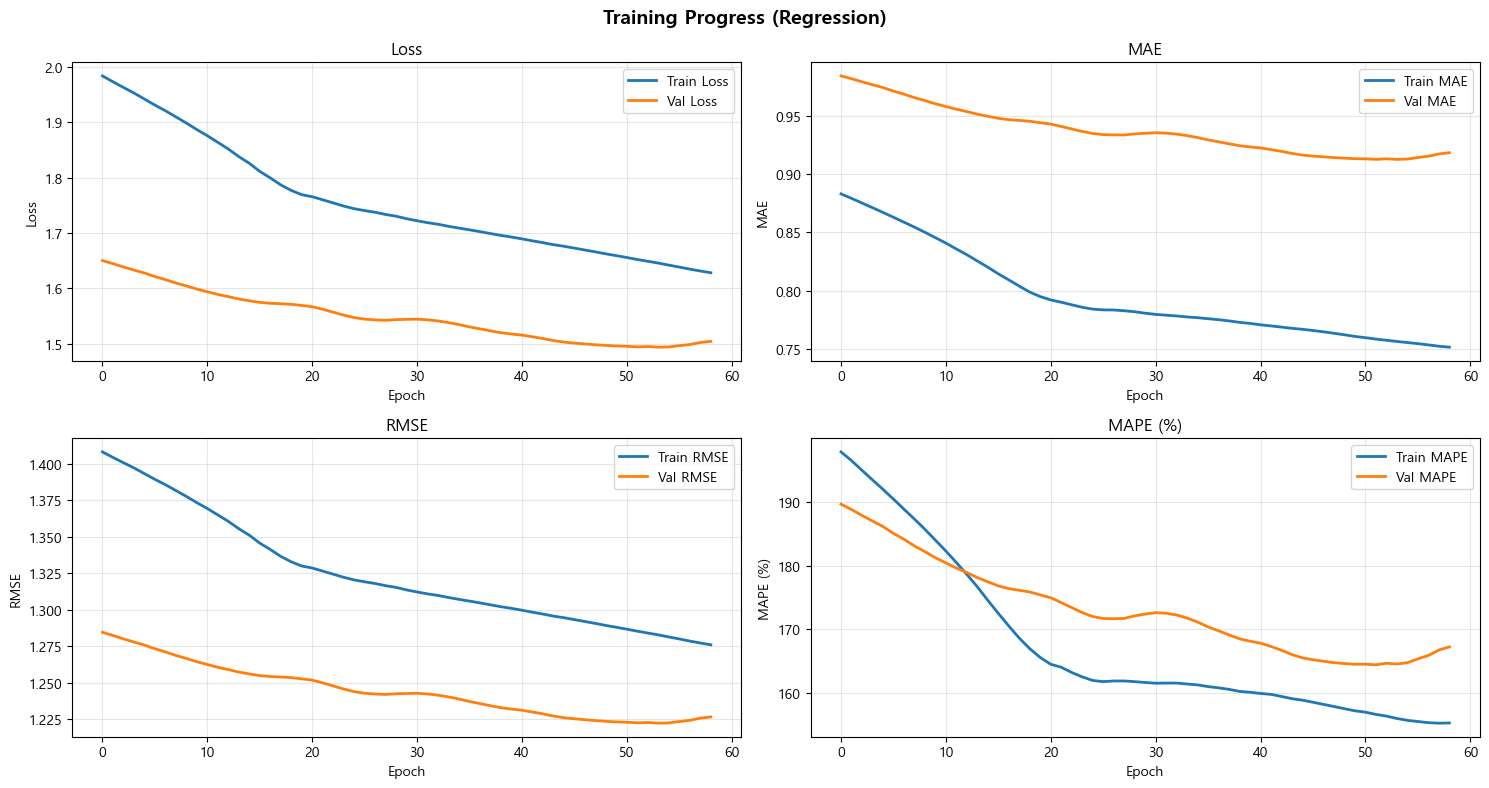

[Test]: 100%|██████████| 1/1 [00:00<00:00, 45.69it/s, loss=6.5119, mae=1.4008, rmse=2.5518]

Loss: 6.5119
MAE : 1.4008
RMSE: 2.5518
MAPE: 162.58%
R² (Output 1): -0.2969

[역정규화 테스트 성능]
  R2  : -1.2068
  MAE : 1.4793
  RMSE: 2.6948
  실제 범위: 2.35 ~ 27.78
  예측 범위: 2.66 ~ 28.94

Predictions denormalized
  Original shape: (229, 1)
  Denormalized shape: (229, 1)

Predictions saved to C:\project_WWTP\python\data\output\toc_predictions.csv


(ARXLSTMAttention(
   (lstm): LSTM(11, 64, batch_first=True)
   (attn): Linear(in_features=64, out_features=1, bias=True)
   (fc): Linear(in_features=64, out_features=1, bias=True)
 ),
 {'train_loss': [1.9832984861728484,
   1.9726614625753494,
   1.9625131979173733,
   1.9524979373407803,
   1.9416053577633507,
   1.9306687602470796,
   1.9204909265711065,
   1.909363756384377,
   1.8982513084840238,
   1.8864930624616036,
   1.875402964659195,
   1.8634920759512772,
   1.8514205781139805,
   1.837785144017836,
   1.8257128728422374,
   1.8110854277450048,
   1.7993379599957957,
   1.7867170090086004,
   1.7767423826048152,
   1.7690925631021455,
   1.7654155798416216,
   1.7598515552933784,
   1.7542411451807305,
   1.7485636132973816,
   1.7438459580229544,
   1.7403774542754955,
   1.7373788114465902,
   1.7333787226701294,
   1.7302777521213302,
   1.725736591009855,
   1.7220918814422406,
   1.7186159305845266,
   1.7157772652827683,
   1.7120759762344127,
   1.7088034710674656,


In [33]:
main()